In [29]:
import json
import math
import os
import pdb
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.functional as TF
from datasets.dataset import SimulationXZDataset
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
from mpl_toolkits.axes_grid1 import make_axes_locatable
from peakdetect import peakdetect
from PIL import Image
from pylab import gca
from runners.train_diffusion import forwardpass
from scipy import interpolate
from scipy.signal import find_peaks
from skimage.metrics import structural_similarity as ssim_id
from sklearn.metrics import mean_absolute_error
from torch.optim import lr_scheduler
from torch.utils import data
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image
from tqdm import tqdm

from analysis_functions import (PSNR, SSIM, get_profile, load_diffusion,
                                load_encoder, load_mobilenet,
                                multifield_plot_images, plot_images,
                                predict_ddim_diffusion, predict_diffusion,
                                predict_lrenc, predict_mobilenet,
                                predict_modified_diffusion)


In [30]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)
        

In [31]:
class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'test_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss

In [32]:
device = 'cuda'
def predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, factor = 2, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = factor)
    shape=hr.shape

    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddpm_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        xs = [x]
        x0_preds = []
        betas = b
        for i, j in zip(reversed(seq), reversed(seq_next)):

            noise = torch.randn_like(x)


            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(betas, t.long())
            atm1 = compute_alpha(betas, next_t.long())
            beta_t = 1 - at / atm1
            x = xs[-1].to('cuda')

            et =model(x, t, x_e)
            # e = output

            x0_from_e = (1.0 / at).sqrt() * x - (1.0 / at - 1).sqrt() * et
            # x0_from_e = torch.clamp(x0_from_e, -1, 1)
            x0_preds.append(x0_from_e.to('cpu'))
            mean_eps = (
                (atm1.sqrt() * beta_t) * x0_from_e + ((1 - beta_t).sqrt() * (1 - atm1)) * x
            ) / (1.0 - at)

            mean = mean_eps
            # noise = torch.randn_like(x)
            mask = 1 - (t == 0).float()
            mask = mask.view(-1, 1, 1, 1)
            logvar = beta_t.log()
            sample = mean + mask * torch.exp(0.5 * logvar) * noise
            # sample = mean + mask * c1 * noise

            # print(torch.sum(sample-xt_next))
            xs.append(sample.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



In [33]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def multifield_plot_images(input, result, target, upscaled_lr, modeltype, field_idx, field_key, split = 'train', timesteps = 200, title = '', timestep = None):
    
    result  = result
    scaling_factor = 1.5
    dpi = 150
    min_temp = 293
    max_temp = 5000
    method = 'Direct'

        
    axis_lim_min= {'vx': -30, 'vy':-30, 'vz':-30, 'temperature':293, 'pressure': 900000, 'liqlabel':0}
    axis_lim_max= {'vx': 30, 'vy':30, 'vz':30, 'temperature':5000, 'pressure': 4*1000000, 'liqlabel':1}
    titles= {'vx': r"$v_x$ [cm/s]", 'vy':r"$v_y$ [cm/s]", 'vz':r"$v_z$ [cm/s]", 'temperature':"T [K]", 'pressure': "P [Pa]", 'liqlabel':"Liquid Volume Fraction"}


    fig=plt.figure(dpi = dpi)
    ax = plt.gca()
    im = ax.imshow(target[field_idx][:60,target.shape[-1]//4:3*target.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,60*5,0*5,40*5])
    frame_tick()
    plt.axis('off')
    cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.025,ax.get_position().height])
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    plt.savefig( title + 'target.png', bbox_inches = 'tight')
    plt.clf()

    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(input[field_idx][:60,input.shape[-1]//4:3*input.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,60*5,0*5,40*5])    
    frame_tick()
    plt.xlabel(r'x $[\mu m]$', fontsize = 14)
    plt.ylabel(r'z $[\mu m]$', fontsize = 14)
    plt.axis('equal')
    plt.savefig( title + 'input.png', bbox_inches = 'tight')

    # plt.show()
    plt.clf()
    plt.figure(dpi = dpi)

    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(result[field_idx][:60,result.shape[-1]//4:3*result.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,60*5,0*5,40*5])
    frame_tick()
    plt.axis('off')
    plt.axis('equal')

    plt.savefig( title + 'result.png', bbox_inches = 'tight')

    plt.figure(dpi = dpi)
    # plt.xlim([0,300])

    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(upscaled_lr[field_idx][:60,result.shape[-1]//4:3*result.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,60*5,0*5,40*5])
    frame_tick()
    plt.axis('off')
    plt.axis('equal')
    plt.savefig( title + 'upscaled_lr.png', bbox_inches = 'tight')

    plt.clf()
    plt.close('all')

In [34]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_images(input, result, target, modeltype, split = 'train', timesteps = 200, title = '', timestep = None, save =False):
    
    result  = result
    scaling_factor = 1.5
    dpi = 150
    min_temp = 293
    max_temp = 5000
    method = 'Direct'
    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    # plt.imshow(input.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # clb = plt.colorbar()

    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    else:
        plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(input[:,input.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    if save:
        plt.savefig( title + 'input.png', transparent = True)
    else:
        plt.show()
    # plt.show()
    plt.clf()
    plt.close('all')
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((target).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    # plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    else:
        plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(target[:,target.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()



    if save:
        plt.savefig( title + 'target.png', transparent = True)
    else:
        plt.show()

    # plt.show()
    plt.clf()

    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((result).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    # plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    else:
        plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(result[:,result.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="5%", pad=0.05)
    # clb=plt.colorbar(im, cax=cax)
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    if save:
        plt.savefig( title + 'result.png', transparent = True)
    else:
        plt.show()

    # plt.show()
    plt.clf()
    plt.close('all')

In [35]:
def plot_srdiff_contours(input, result, target, modeltype, split = 'train', max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Direct', save = False, mpfname = '', kpfname = ''):
    profile_result, kp_result = get_profile(result, mesh = 10, max_idx = 30)

    profile_gt, kp_gt = get_profile(target, mesh = 10, max_idx = 30)
    profile_input, kp_input = get_profile(input, mesh = 10, max_idx = 15)

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),100 +  kp_input*20 - 400, '--', label = 'Bicubic Interpolation')
    plt.plot(10*np.arange(40), 100 + kp_result*10 - 400, label = 'Encoder Output' )
    plt.plot(10*np.arange(40), 100 + kp_gt*10 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()

    legend()
    plt.ylim([-200, 0])
    plt.title('[{} Data] Keyhole Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        # print('Saving')
        plt.savefig(kpfname, bbox_inches = 'tight')
    else:
        plt.show()

    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),100 + profile_input*20 - 400, '--', label = 'Bicubic Interpolation')
    plt.plot(10*np.arange(40), 100 + profile_result*10 - 400, label = 'Encoder Output' )
    plt.plot(10*np.arange(40),100 + profile_gt*10 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    plt.ylim([-200, 0])

    frame_tick()

    legend()
    plt.ylim([-200, 0])
    plt.title('[{} Data] Melt Pool Depth, {}'.format(split, modeltype), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    if save:
        
        plt.savefig(mpfname, bbox_inches = 'tight')
    else:
        plt.show()
    plt.close('all')
    # plt.show()

In [36]:
def get_profile(image, mesh = 5, max_idx = None):
    image = image[0].T
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:
            profile.append(np.min(coords))
            keyholeprofile.append(np.max(coords))
        else:
            if max_idx == None:

                profile.append(binarized.shape[1])
                keyholeprofile.append(binarized.shape[1])
            else:
                profile.append(max_idx)
                # keyholeprofile.append(binarized.shape[1])
                keyholeprofile.append(max_idx)
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    return(profile, keyholeprofile)

In [37]:

device = 'cuda'


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = 2)
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float(), factor = 2)
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b





In [38]:
def get_frequency(seq):
    peaks = peakdetect(seq, lookahead=1) 
    higherPeaks = np.array(peaks[0])
    lowerPeaks = np.array(peaks[1])
    print(higherPeaks)
    if len(higherPeaks) == 0:
        return 0, 0
    mask1 = higherPeaks[:,0] > 30 
    mask2 =  higherPeaks[:,0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(higherPeaks[indices][:,0])*5e-6)
    amp = np.std(10e-6*np.diff(higherPeaks[indices][:,0]))
    print(frequency, amp)
    return frequency, amp
def get_frequency_old(seq):
    peaks = find_peaks(seq)
    if len(peaks[0]) == 0:
        return 0, 0
    mask1 = peaks[0] > 30 
    mask2 =  peaks[0] < 80 
    indices = np.logical_and(mask1, mask2)
    frequency = 1/np.mean(np.diff(peaks[0][indices])*5e-6)
    amp = np.std(10e-6*np.diff(peaks[0][indices]))
    print(frequency, amp)
    return frequency, amp

In [39]:

def SSIM(op, t, batch_size):
    ssim = 0 
    # print(op.shape, t.shape)
    
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        if isinstance(op, torch.Tensor):
            score = ssim_id(op[i][0].detach().cpu().numpy(), t[i][0].detach().cpu().numpy())#, full=True)
        else:
            score = ssim_id(op[i][0], t[i][0].detach().cpu().numpy())#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim

In [40]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_20_16_01_36/rescaling/n_steps_1'#'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_17_03_43_34/rescaling/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_01_36/rescaling/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_17_03_43_34/rescaling/n_steps_1'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/mobilenet/2022_12_05_03_17_09'


In [41]:
from datasets.dataset import SimulationXZDataset
image_size = 80
channels = 1
batch_size =16
field_names = ['temperature']
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields


In [42]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "4"
device = 'cuda'
criterion = torch.nn.L1Loss()
multi_field_results_dir = 'expanded_results'
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
model = load_diffusion(diffusion_results_dir, dataset = train_dataset)
batch_size = 2
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)



 42%|████▏     | 1709/4094 [00:03<00:04, 478.60it/s]


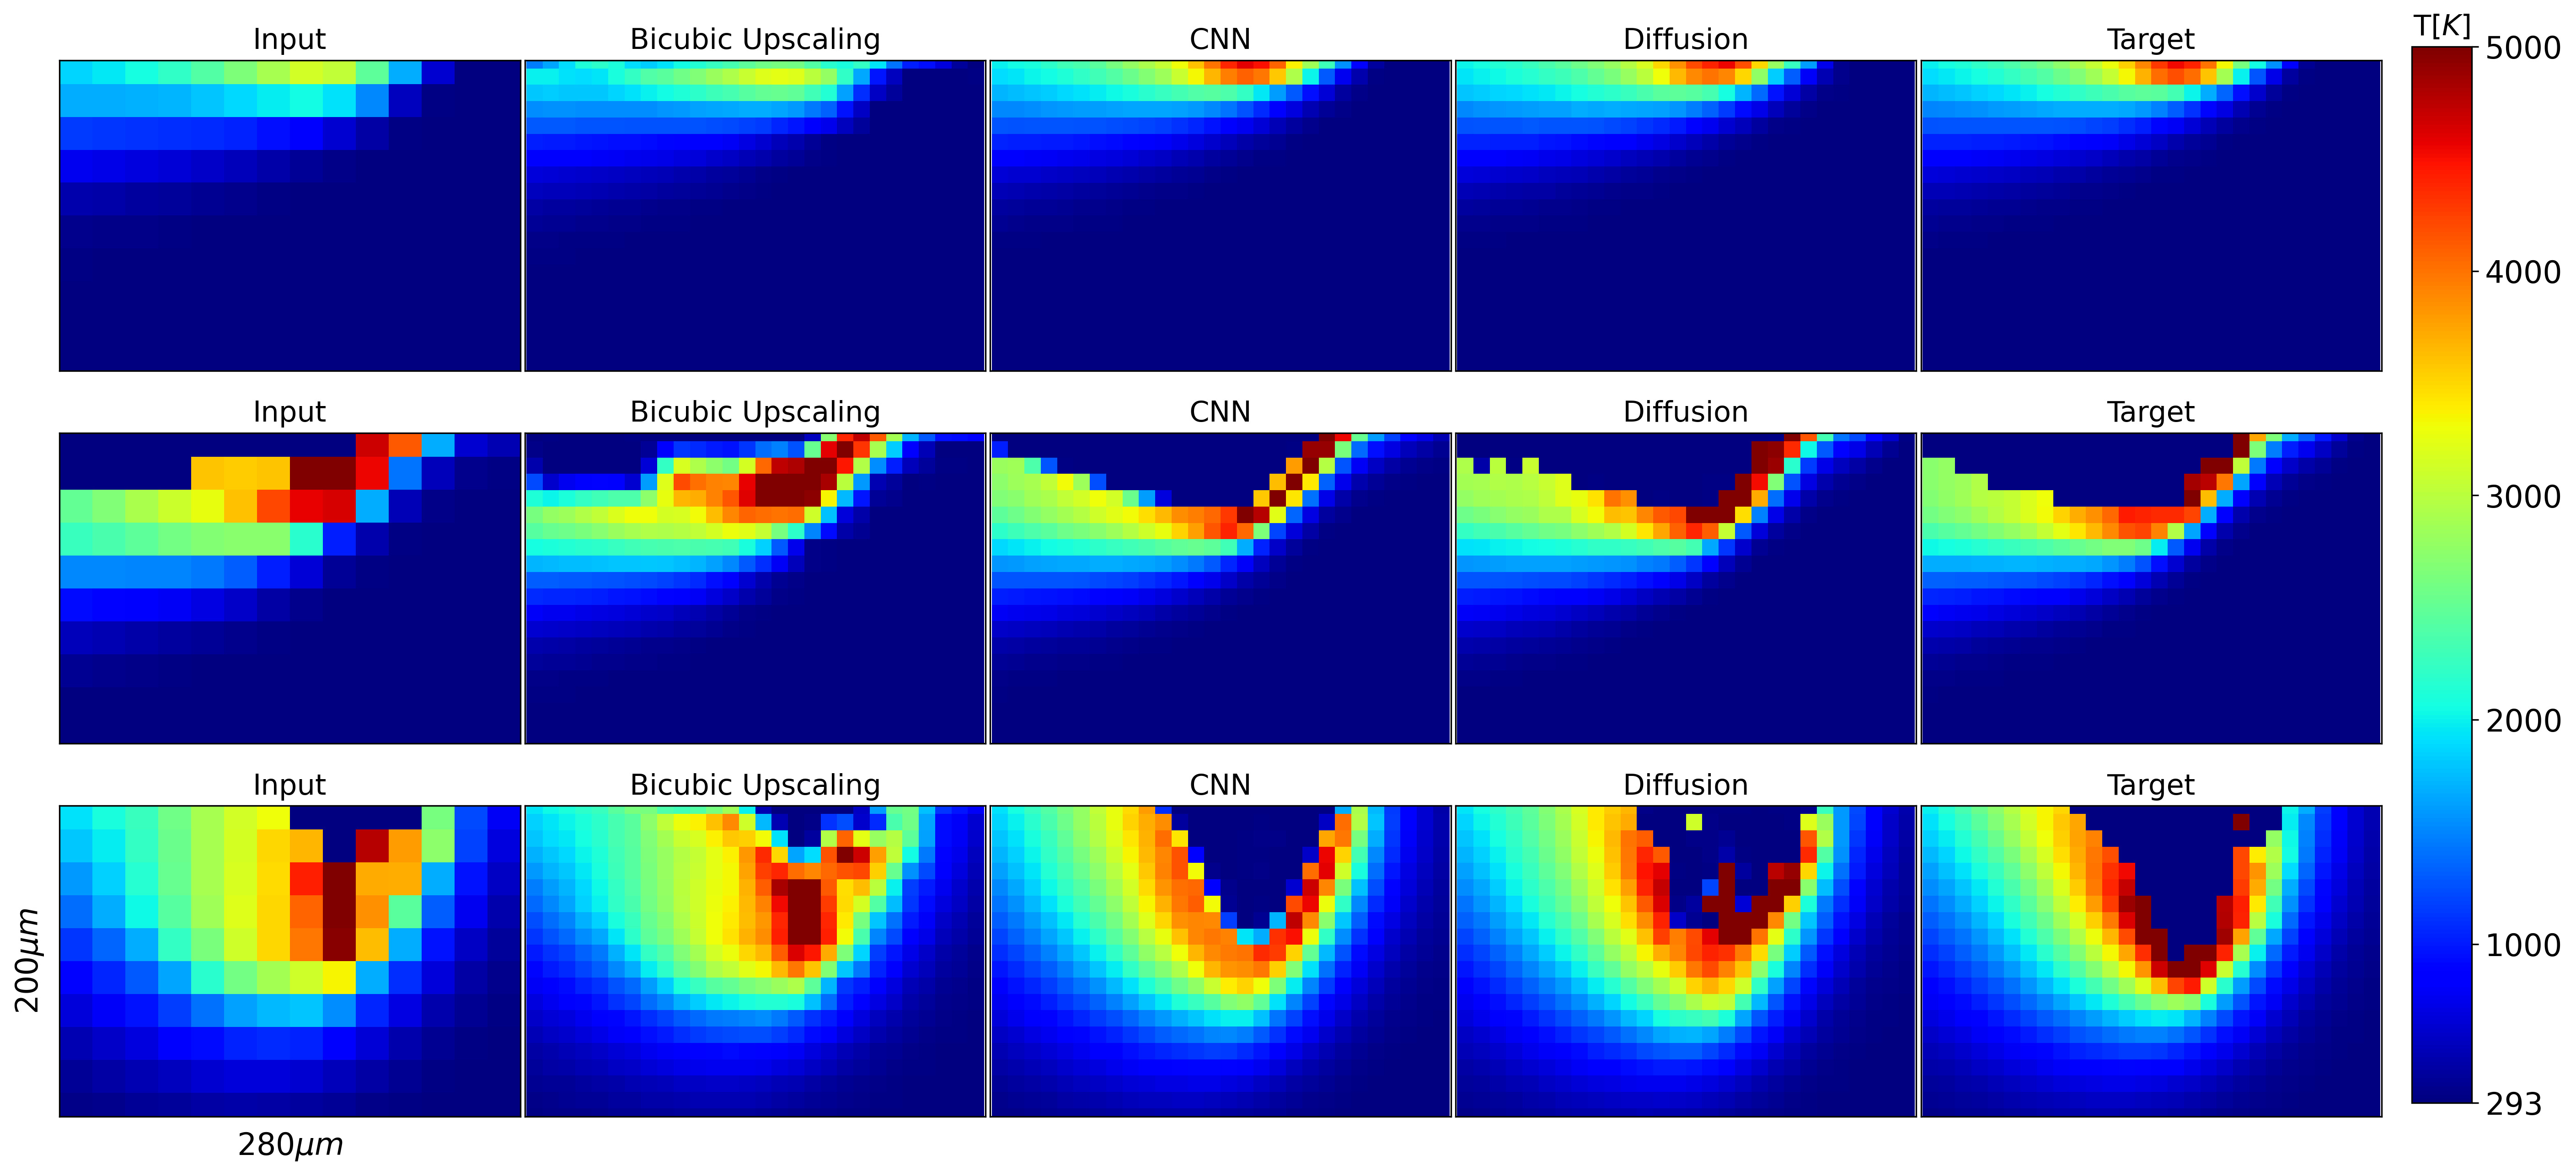

 52%|█████▏    | 2137/4094 [00:03<00:03, 643.32it/s]


KeyboardInterrupt: 

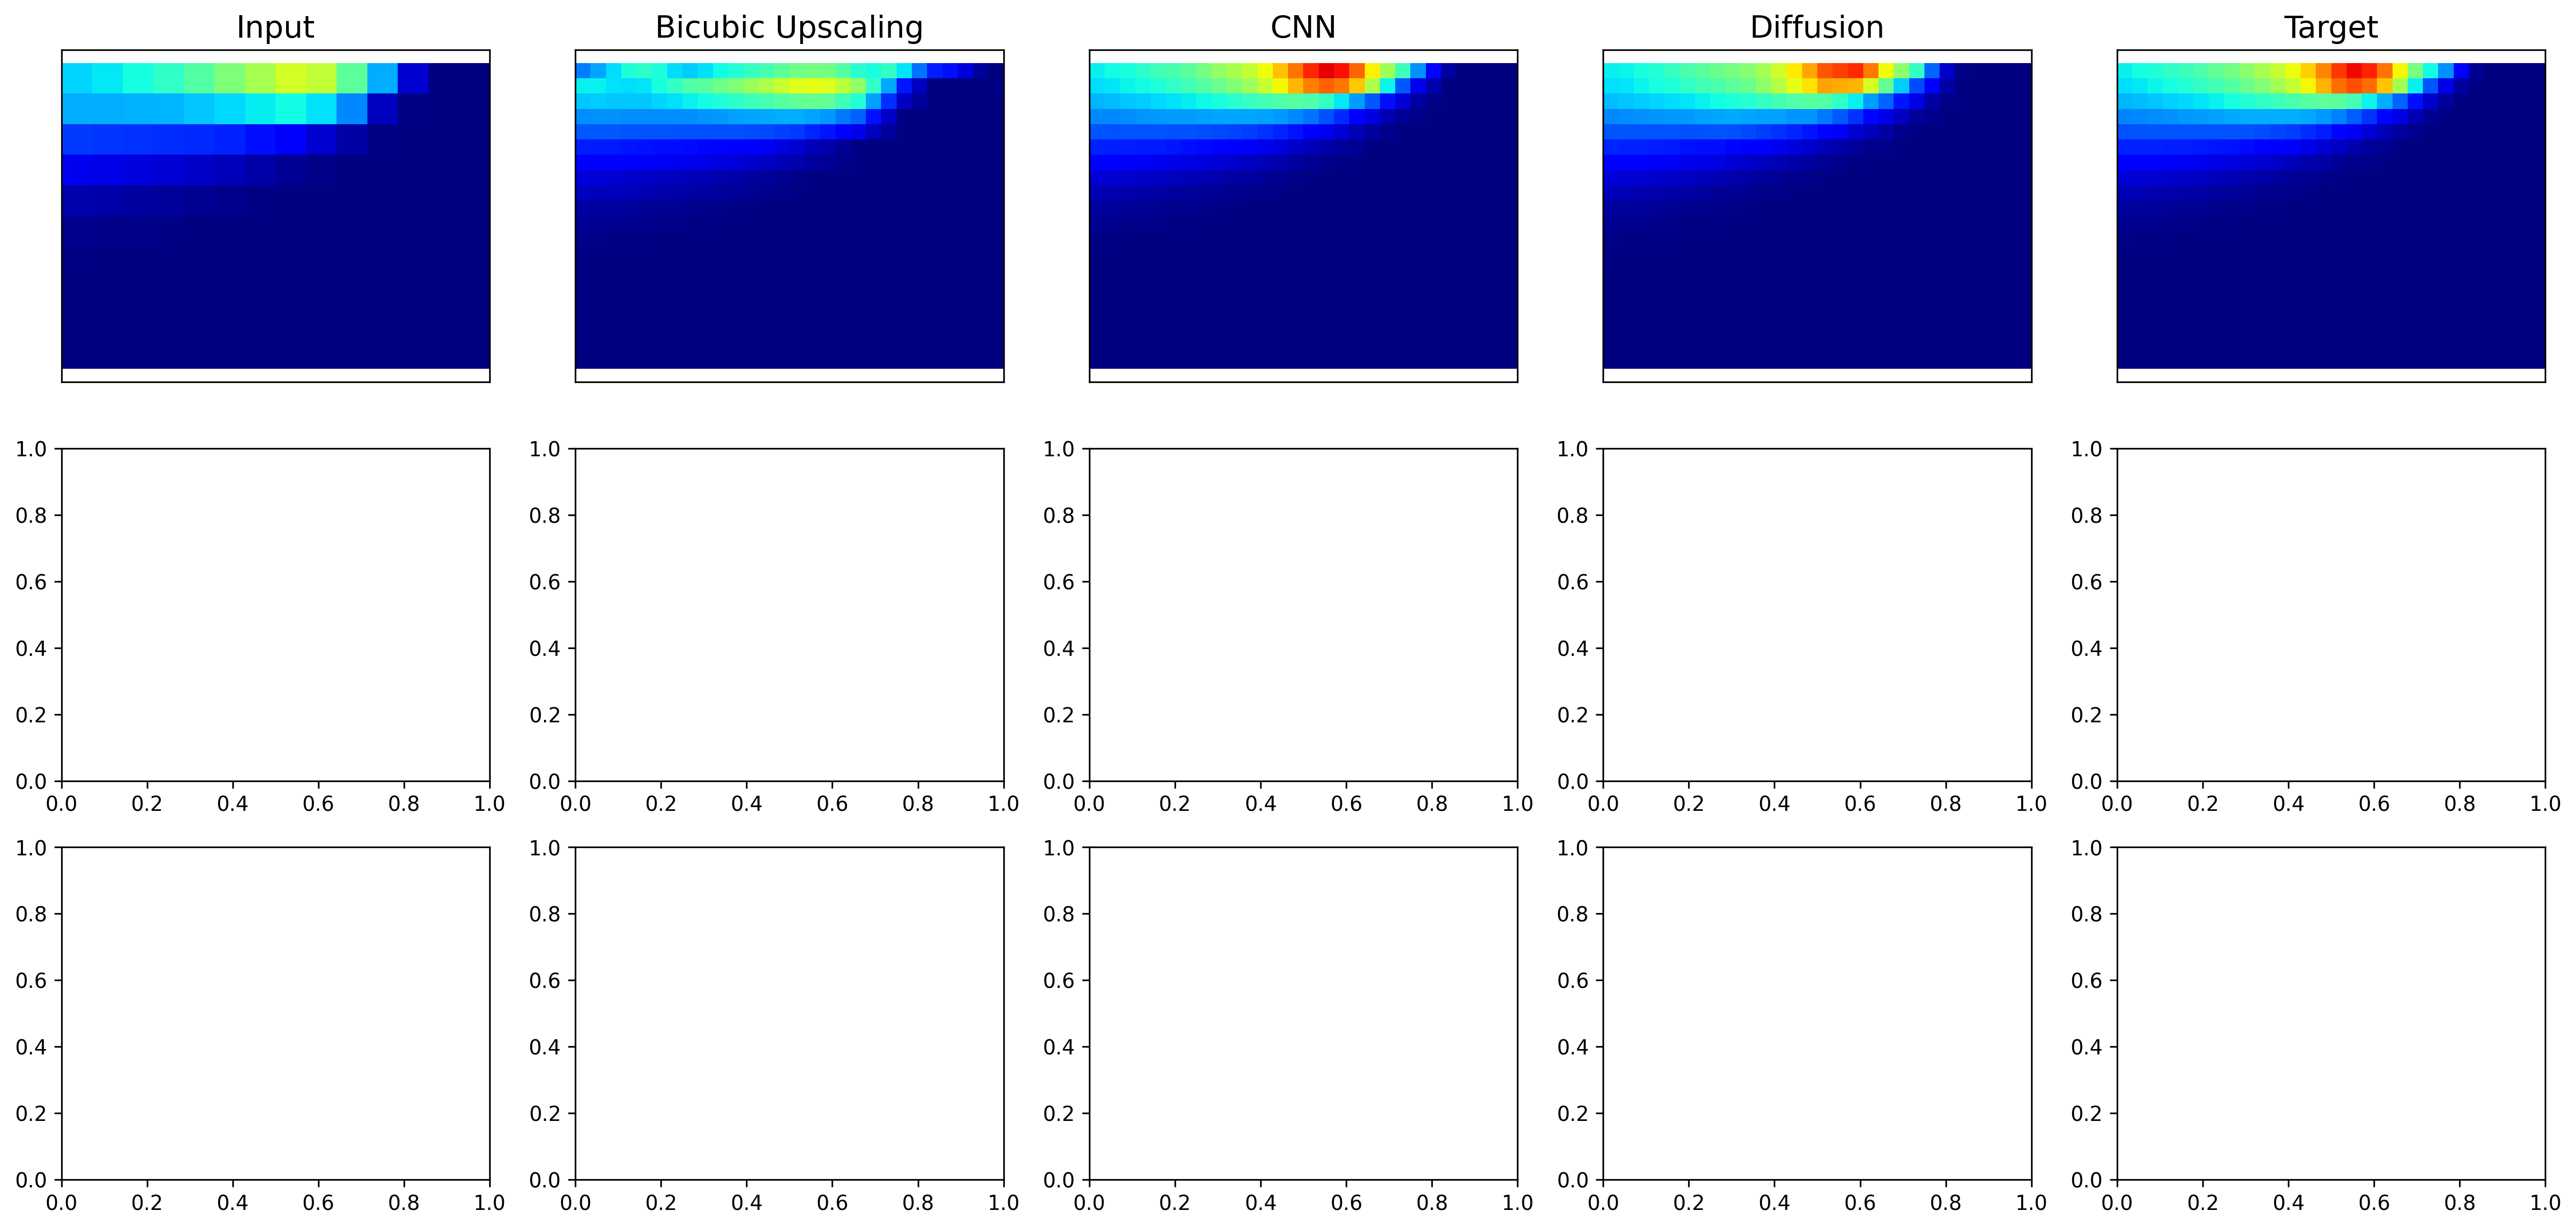

In [43]:
# for array in [input, upscaled_lr_data, result_diffusion, target]:
field_idx  =0
scaling_factor = 1
timestep = 1000
skip = 10
labels = ['Input', 'Bicubic Upscaling', 'CNN', 'Diffusion', 'Target']
batch_idxs = [399,2617,1708] # 130v1300 190v250 400v650
# batch_idxs = [0,1,2]
for k in range(50):
    fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(2.8*7.8*scaling_factor, 10*scaling_factor), dpi=300)
    fig.patch.set_alpha(0)
    for j,(row, batch_index) in enumerate(zip(axs, batch_idxs)):
        for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader) ):
            if batch_idx == batch_index:
                input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
                input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timestep,skip = skip, schedule = 'linear')
                upscaled_lr_data = test_dataloader.dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
                for i, (ax, array, label) in enumerate(zip(row,[input, upscaled_lr_data, result, result_diffusion, target], labels )):
                    if i == 0:
                        division_factor = 2
                    else:
                        division_factor  = 1
                    xx, yy = np.meshgrid(np.arange(28//division_factor)*10*division_factor, np.arange(20//division_factor)*10*division_factor)
                    
                    im = ax.pcolormesh(xx, yy, array[field_idx][0,2//division_factor:30//division_factor,array.shape[-1]//4:3*array.shape[-1]//4].T, vmin=293, vmax=5000, cmap='jet')
                    ax.axis('equal')
                    ax.set_ylim([yy.min(), yy.max()])
                    # if i ==  0 and j == 0:
                        
                        
                        # frame_tick()
                    # else:
                    # ax.axis('off')
                    ax.set_title(label, fontsize = 15)
                    ax.xaxis.set_tick_params(labelbottom=False)
                    ax.yaxis.set_tick_params(labelleft =False)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    if j == len(axs) - 1  and i == 0:
                        # ax.set_ylabel(r'z $[\mu m]$')
                        # ax.set_xlabel(r'x $[\mu m]$')
                        ax.set_ylabel(r'200$\mu m$', fontsize = 16)
                        ax.set_xlabel(r'280$\mu m$', fontsize = 16)
            elif batch_idx > batch_index:
                break
            
    fig.subplots_adjust(wspace = 0.01)#, hspace = 0.1)
    # fig.subplots_adjust()

    # Add colorbar
    cax = fig.add_axes([0.91, 0.12, 0.02, 0.77])
    clb = fig.colorbar(im, cax=cax)
    clb.ax.tick_params(labelsize = 16)
    clb.set_ticks([293, 1000, 2000, 3000, 4000, 5000])
    clb.ax.set_title(r'T$[K]$', fontsize=15)
    plt.show()


In [34]:
last_power = ''
modeltype = 'Encoder' # Defines part of the title of the image
enc_depths_sim = []
diff_depths_sim = []
gt_depths_sim = []

enc_kp_sim = []
diff_kp_sim = []
gt_kp_sim = []
gt_results = {}
enc_results = {}
diff_results = {}
mesh_hr = 10
factor = 2
skip = 50
timesteps  =1000
for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):  
   

    oldtime = time.time()

    input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    # print(timesteps, skip)
    input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
    info = info[0] # info is technically returned with an extra dimension, this command removes it.
    time_elapsed = time.time()-oldtime
    # print(last_power)
    if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
        
        timestep = 0

        enc_depths_sim = []
        diff_depths_sim = []
        gt_depths_sim = []

        enc_kp_sim = []
        diff_kp_sim = []
        gt_kp_sim = []

    else:
        timestep += 1
    # print(target.shape)
    profile_gt, kp_gt = get_profile(target[0], mesh = 10, max_idx = 30)
    profile_input, kp_input = get_profile(input[0], mesh = 20,max_idx = 15)
    profile_diff, kp_diff = get_profile(result_diffusion[0], mesh = 10, max_idx = 30)
    # profile_gt, kp_gt = get_profile(target[0])
    profile_enc, kp_enc = get_profile(result[0], mesh = 10, max_idx = 30)


    enc_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_enc)))
    gt_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_gt)))
    diff_kp_sim.append(mesh_hr*(20*factor-5*factor - np.min(kp_diff)))
    # diff_kp_sim.append(5*(80-np.min(kp_diff)))

    enc_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_enc)))
    gt_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_gt)))
    diff_depths_sim.append(mesh_hr*(20*factor-5*factor - np.min(profile_diff)))

    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
    gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
    enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
    diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_kp_sim
    gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
    enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
    diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_depths_sim
    # if batch_idx > 3:

100%|██████████| 4094/4094 [16:26<00:00,  4.15it/s]


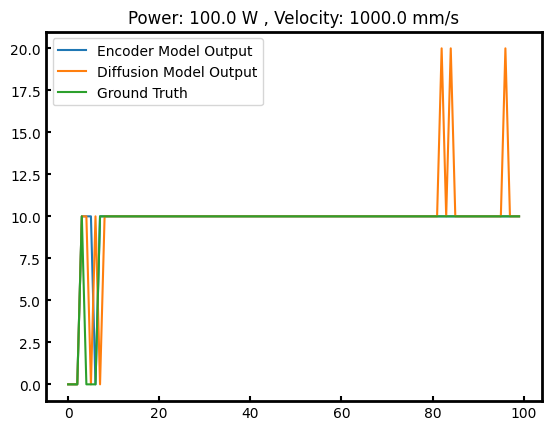

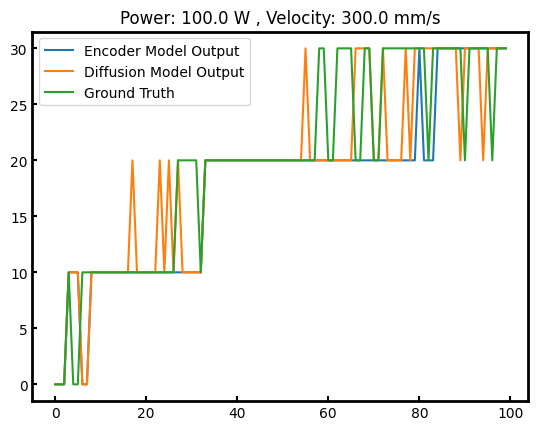

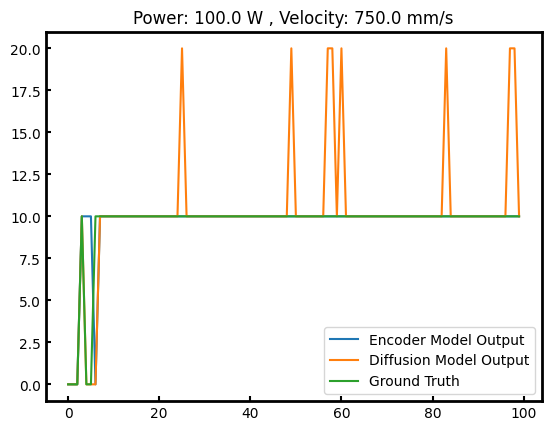

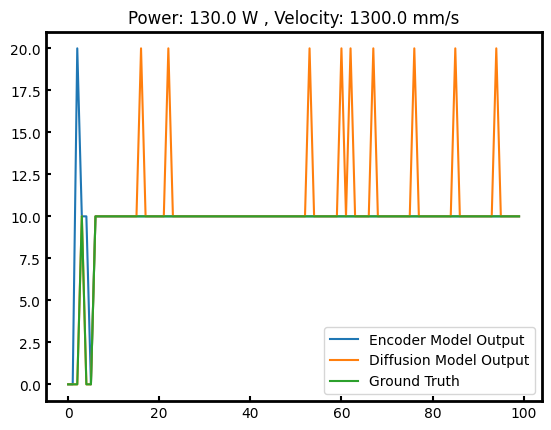

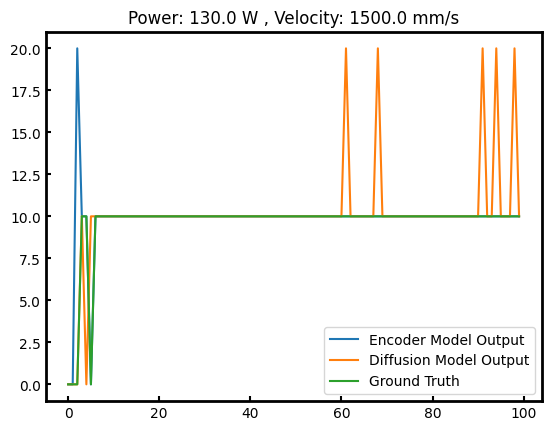

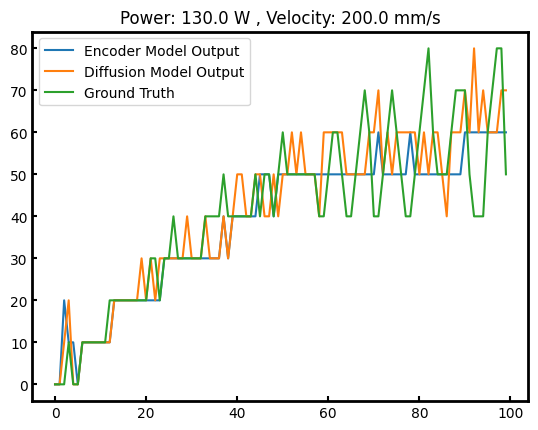

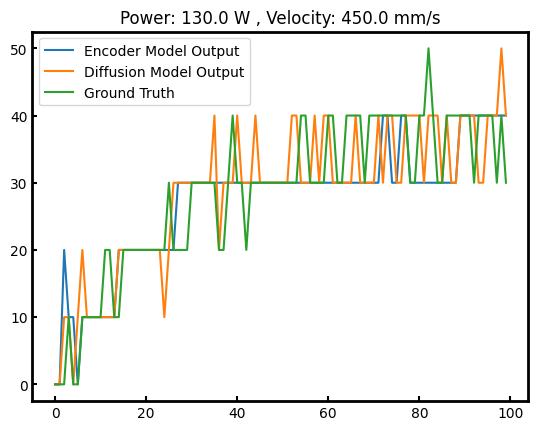

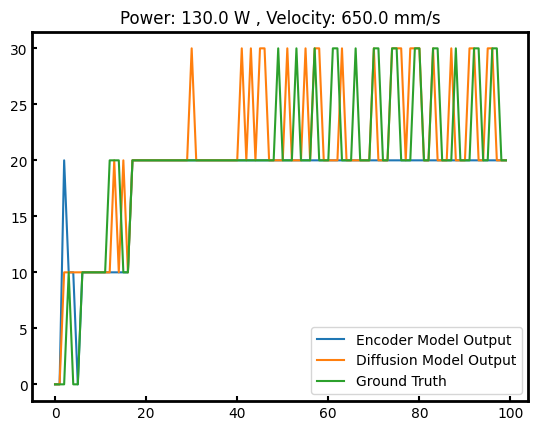

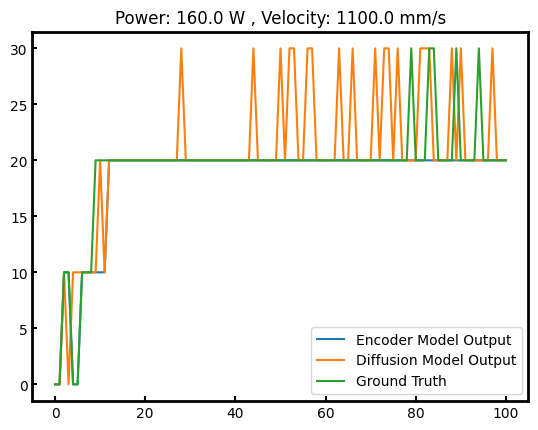

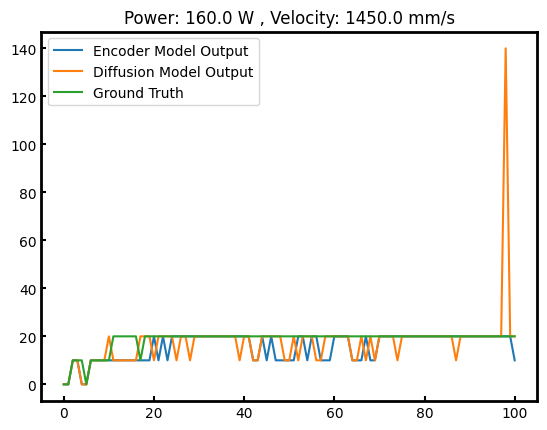

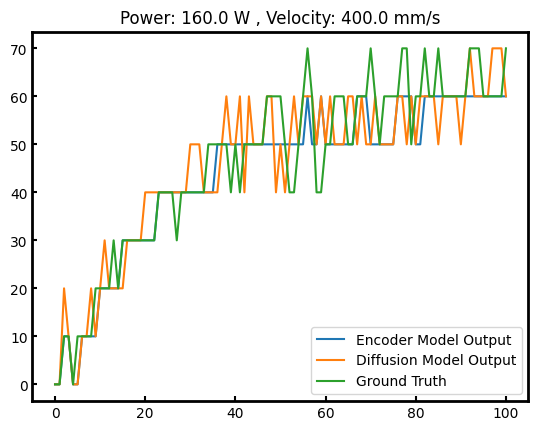

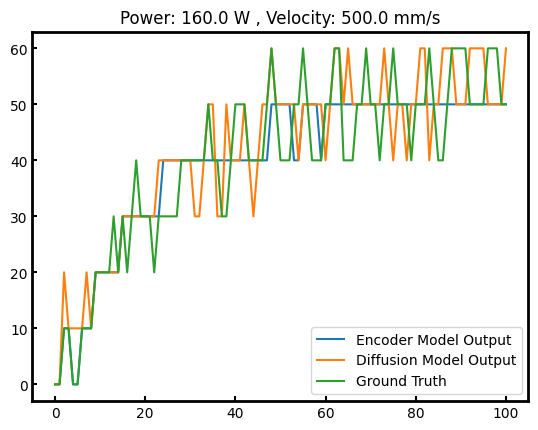

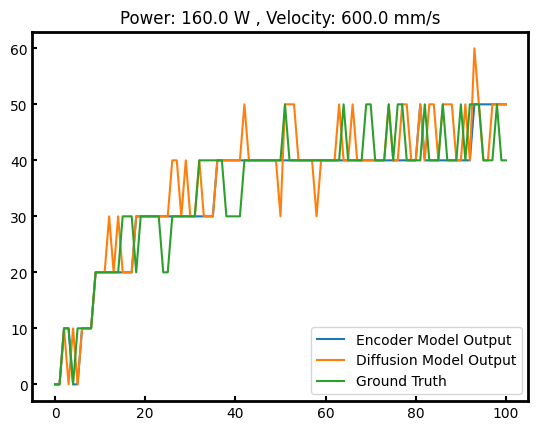

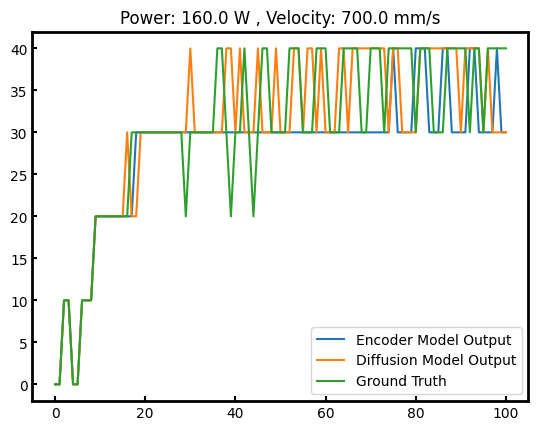

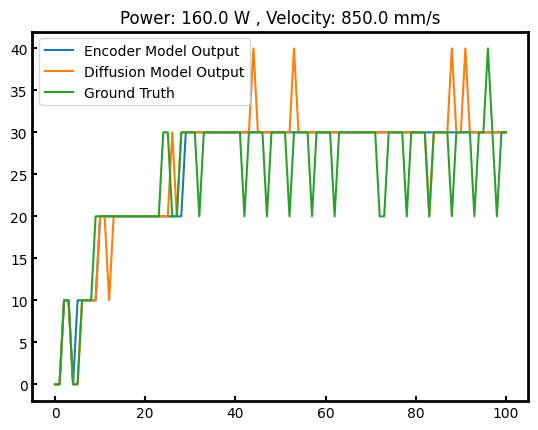

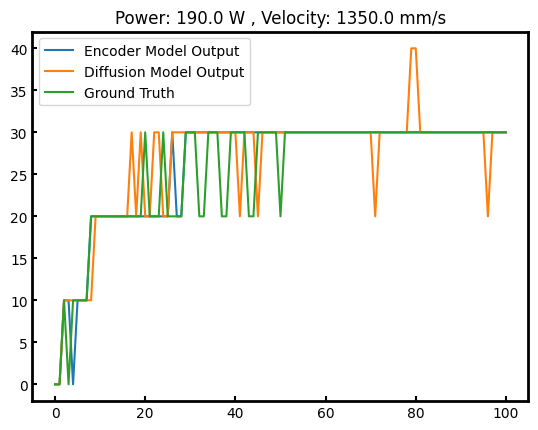

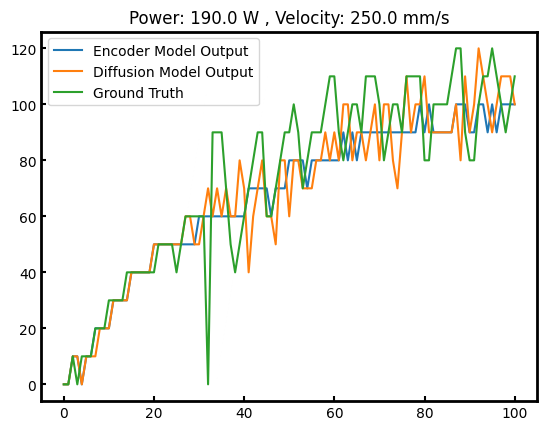

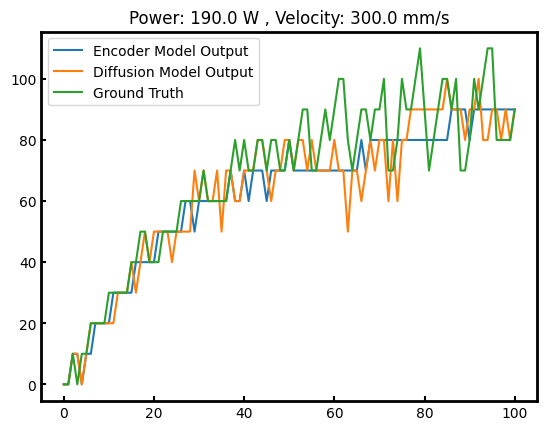

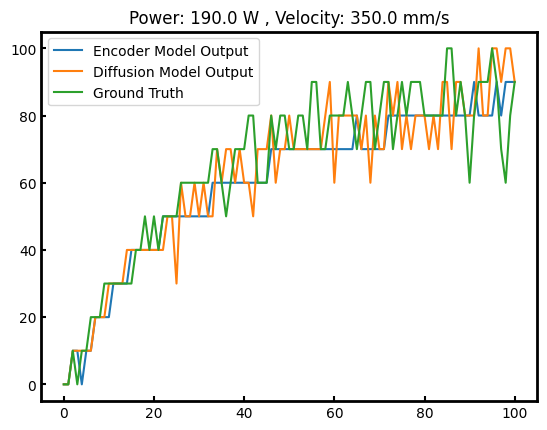

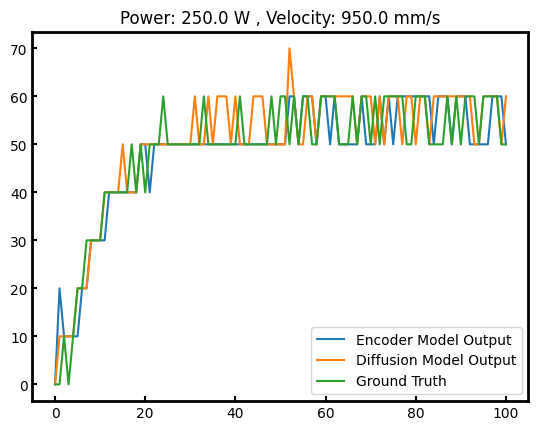

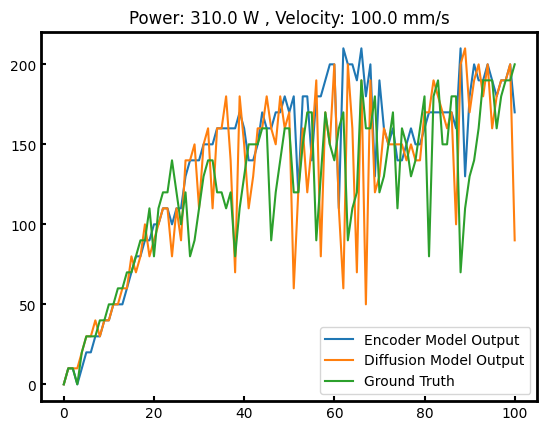

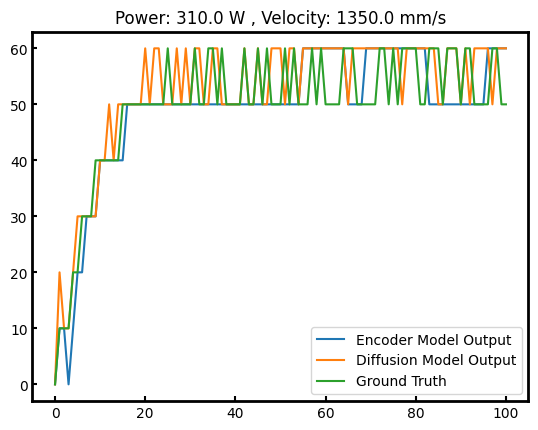

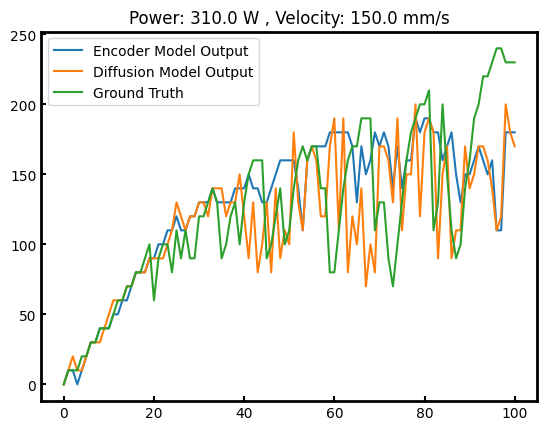

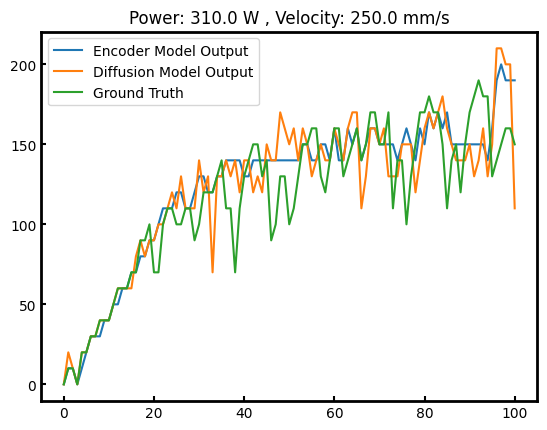

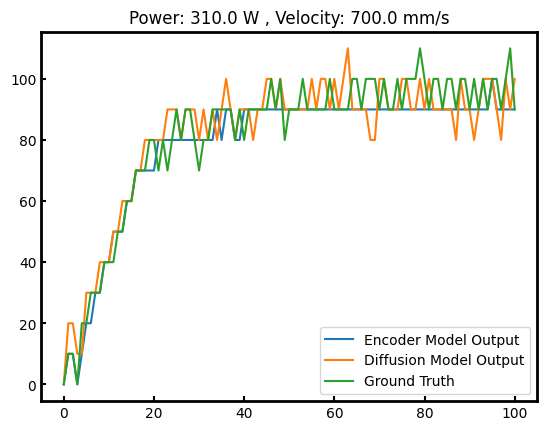

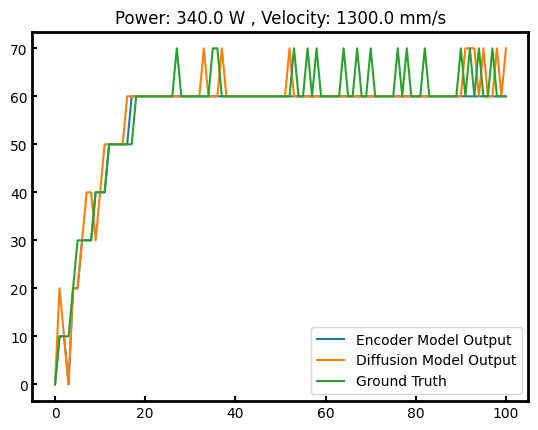

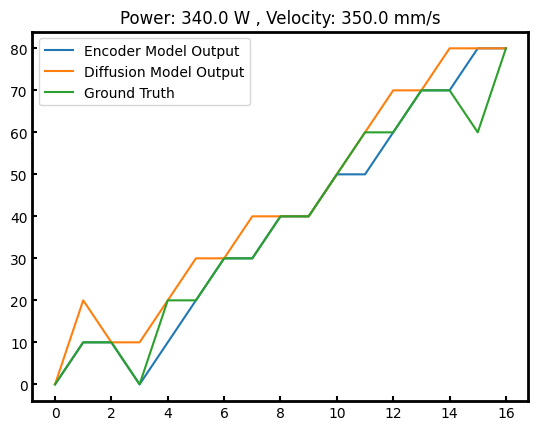

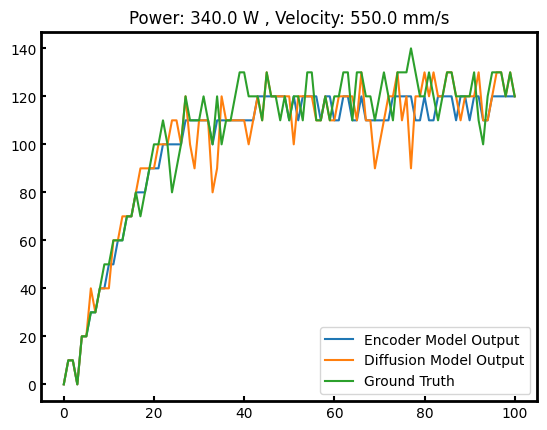

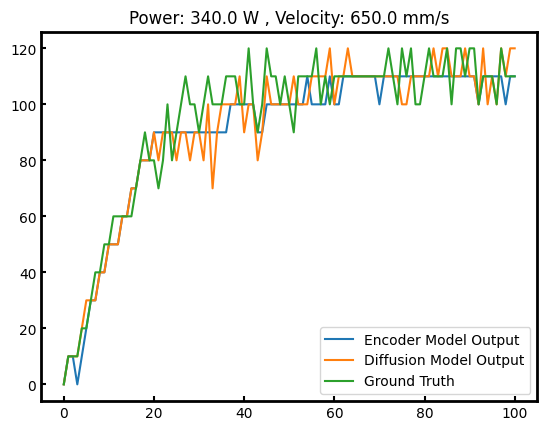

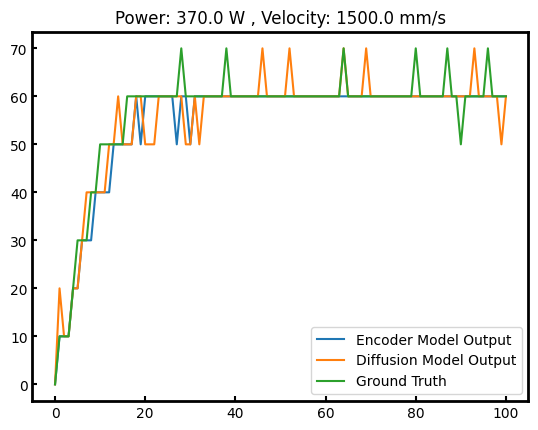

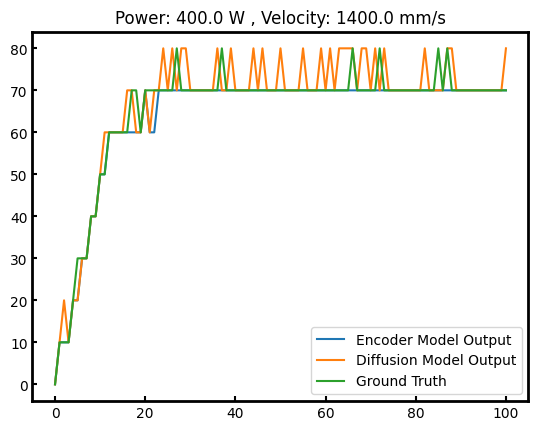

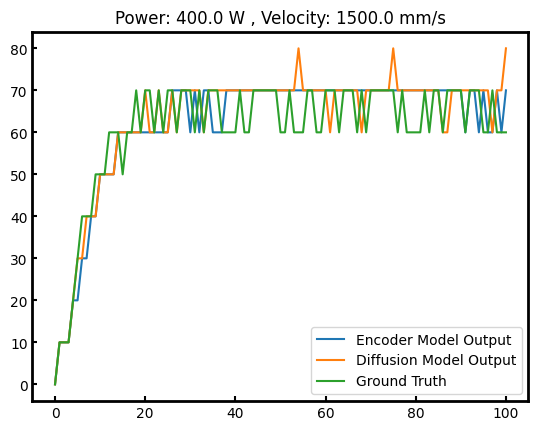

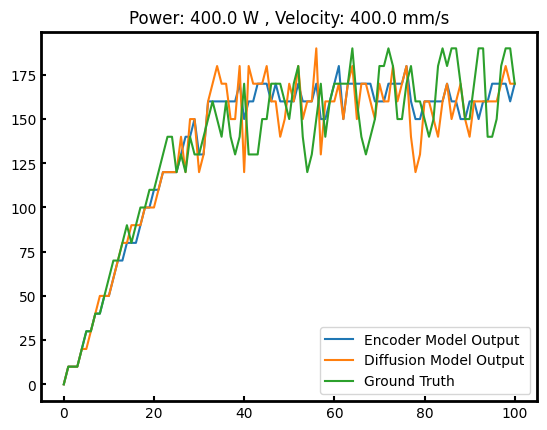

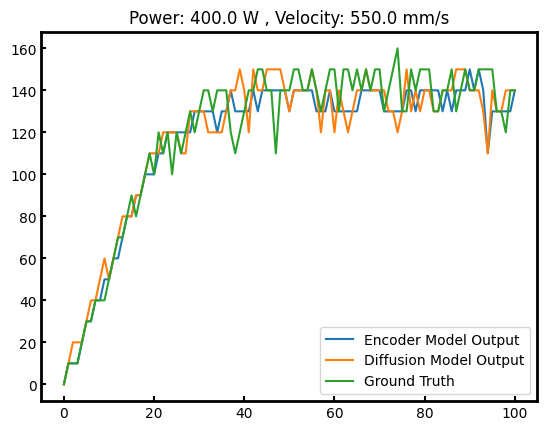

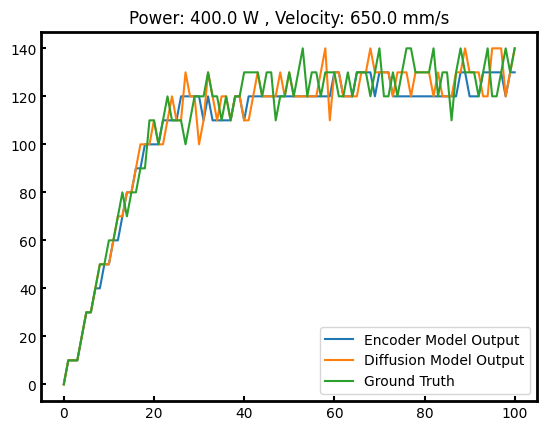

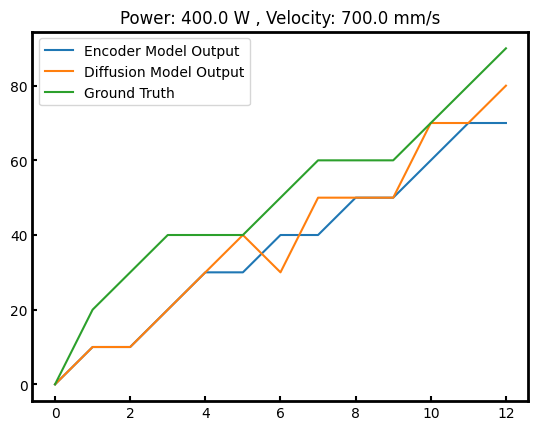

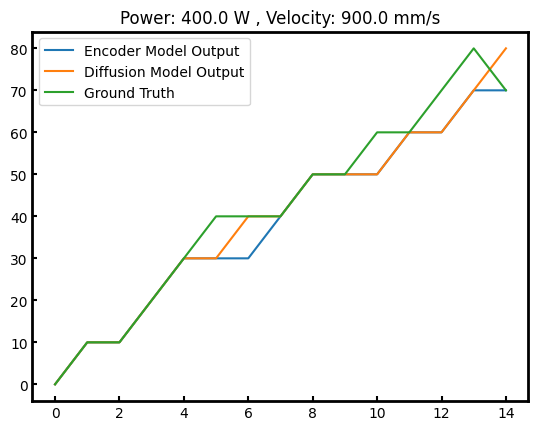

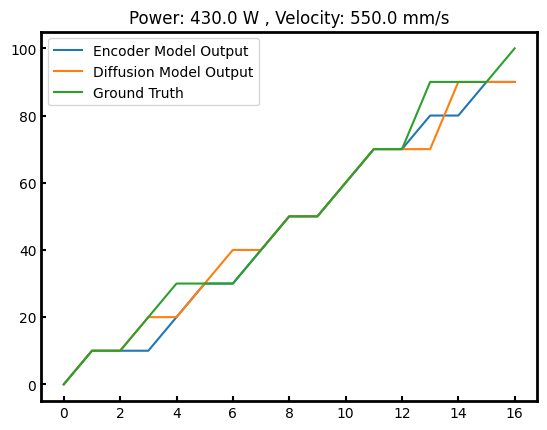

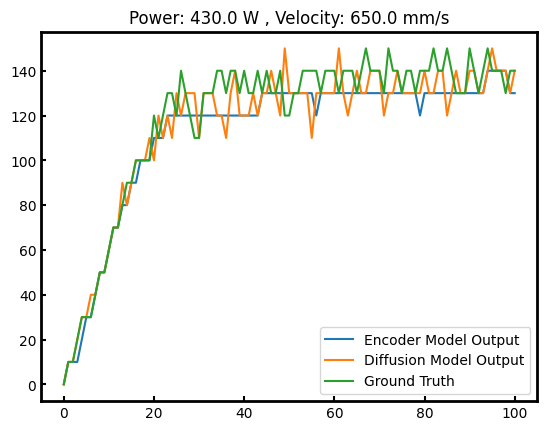

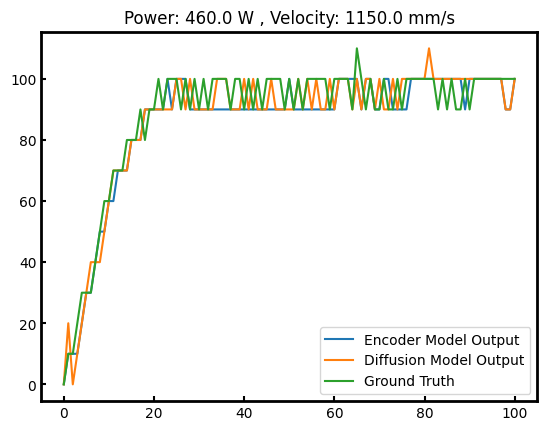

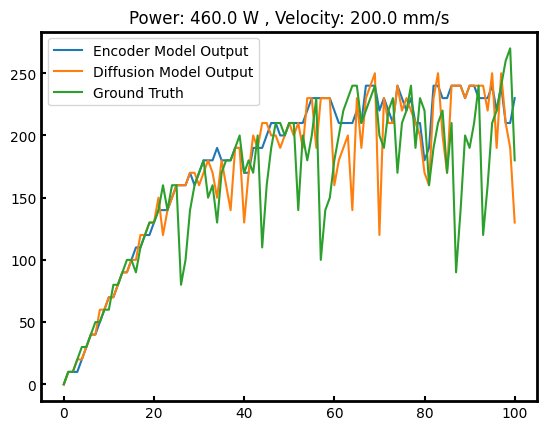

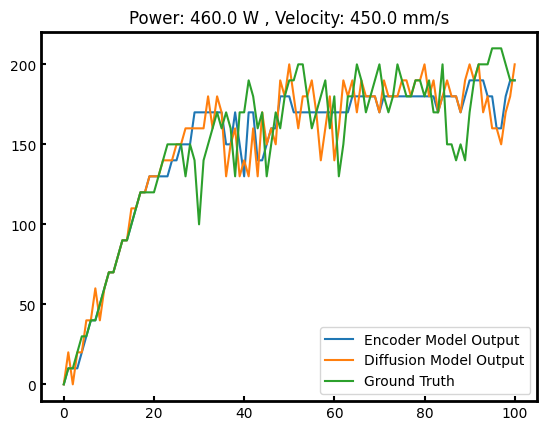

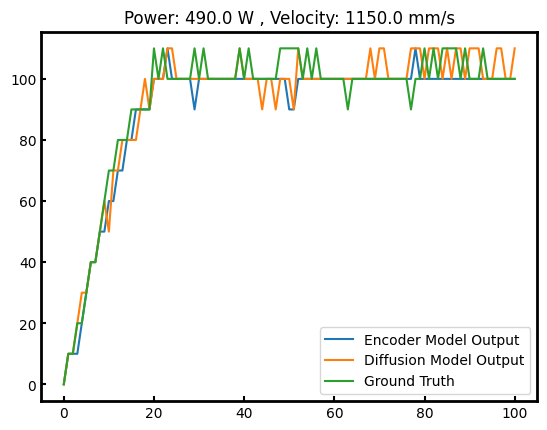

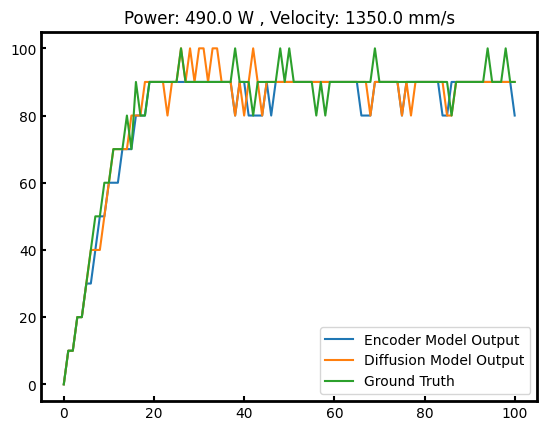

<Figure size 640x480 with 0 Axes>

In [35]:
analysis_folder = f'analyzed_figures_paper_4_24/{timesteps}'
depth_folder = os.path.join(analysis_folder, 'depth_over_time')
from peakdetect import peakdetect
from scipy.signal import find_peaks
os.makedirs(depth_folder, exist_ok = True)
for key in enc_results.keys():
    if 'key' in key:
        plt.plot(enc_results[key], label = 'Encoder Model Output')
        plt.plot(diff_results[key], label = 'Diffusion Model Output')
        plt.plot(gt_results[key], label = 'Ground Truth')
        power_text = key.split('power')[1].split('vel')[0]
        vel_text = key.split('vel')[1]


        
        peaks = find_peaks(gt_results[key])
        # plt.scatter(peaks[0], np.array(diff_results[key])[peaks[0]])
        # peaks = peakdetect(diff_results[key]) 
        # higherPeaks = np.array(peaks[0])
        # lowerPeaks = np.array(peaks[1])
        # plt.step(np.arange(99), diff_results[key])
        # plt.plot(higherPeaks[:,0], higherPeaks[:,1], 'ro', markersize = 4)
        # plt.plot(lowerPeaks[:,0], lowerPeaks[:,1], 'ko' , markersize = 4)


        plt.title(f'Power: {power_text} W , Velocity: {vel_text} mm/s')
        frame_tick()
        plt.legend()
        plt.show()
        # plt.savefig(os.path.join(depth_folder, f'{key}.png'))
        plt.clf()

key_power100.0vel1000.0
nan nan
nan nan
nan nan
depth_power100.0vel1000.0
key_power100.0vel300.0
33333.333333333336 1.4142135623730953e-05
27272.727272727272 3.299831645537222e-05
nan nan
depth_power100.0vel300.0
key_power100.0vel750.0
nan nan
36363.63636363636 2.5e-05
nan nan
depth_power100.0vel750.0
key_power130.0vel1300.0
nan nan
34782.608695652176 2.5860201081971505e-05
nan nan
depth_power130.0vel1300.0
key_power130.0vel1500.0
nan nan
28571.42857142857 0.0
nan nan
depth_power130.0vel1500.0
key_power130.0vel200.0
32432.43243243243 2.793842435706702e-05
45454.545454545456 2.2891046284519194e-05
14634.146341463413 8.055363982396382e-05
depth_power130.0vel200.0
key_power130.0vel450.0
24390.24390243902 3.54400902933387e-05
41860.46511627906 1.8724777273725244e-05
49999.99999999999 0.0
depth_power130.0vel450.0
key_power130.0vel650.0
46666.66666666666 4.517539514526256e-06
47368.42105263158 1.8121673811444545e-05
nan nan
depth_power130.0vel650.0
key_power160.0vel1100.0
nan nan
49999.99999

/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/oogoke/anaconda3/envs/stylegan/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


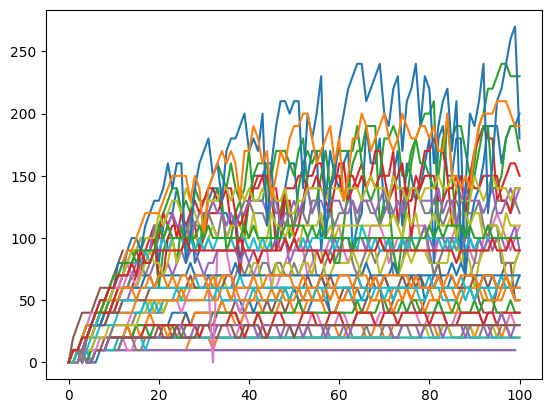

In [36]:
powers = []
vels = []
gtfreqs = []
diffreqs = []
encfreqs = []
encamps= []
gtamps = []
diffamps = []
for key in gt_results.keys():
    print(key)
    if 'key' in key:
        power = float(key.split('power')[1].split('vel')[0])
        vel = float(key.split('vel')[1])
        powers.append(power)
        vels.append(vel)
        plt.plot(gt_results[key])
        gtfreq, amp = get_frequency_old(gt_results[key])
        gtfreqs.append(gtfreq)
        gtamps.append(amp)
        diffreq, amp = get_frequency_old(diff_results[key])
        diffreqs.append(diffreq)
        diffamps.append(amp)
        encfreq, amp = get_frequency_old(enc_results[key])
        encfreqs.append(encfreq)
        encamps.append(amp)

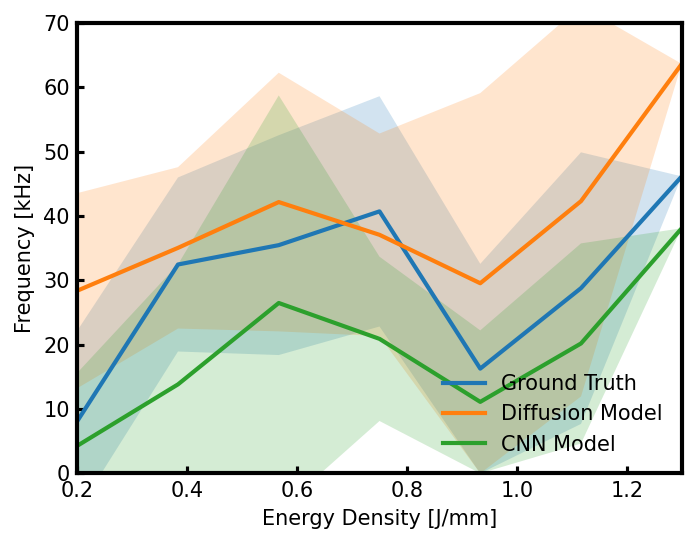

In [37]:
nanreplace_encfreqs = np.copy(encfreqs)
nanreplace_encfreqs[np.isnan(encfreqs)] = 0

nanreplace_diffreqs = np.copy(diffreqs)
nanreplace_diffreqs[np.isnan(diffreqs)] = 0


nanreplace_gtfreqs = np.copy(gtfreqs)
nanreplace_gtfreqs[np.isnan(gtfreqs)] = 0
# bins = np.linspace(0.2,0.8, 15 )
bins = np.linspace(0.2,1.3, 7 )
gtmeans = []
gtstds = []
diffmeans = []
diffstds = []
encmeans = []
encstds = []
digitized_density = np.digitize(np.array(powers)/np.array(vels), bins)
for idx, bin in enumerate(bins):
    gtarray = np.array(nanreplace_gtfreqs)[digitized_density == idx]/1000
    diffarray = np.array(nanreplace_diffreqs)[digitized_density == idx]/1000
    encarray = np.array(nanreplace_encfreqs)[digitized_density == idx]/1000

    gtmean = np.mean(gtarray)
    encmean = np.mean(encarray)
    # diffmean = np.mean(diffarray)

    gtstd = np.std(gtarray)
    encstd = np.std(encarray)
    # diffstd = np.std(diffarray)

    gtstd = np.std(gtarray)
    gtmean = np.mean(gtarray)
    encstd = np.std(encarray)
    encmean = np.mean(encarray)
    diffstd = np.std(diffarray)
    diffmean = np.mean(diffarray)

    gtmeans.append(gtmean)
    gtstds.append(gtstd)


    encmeans.append(encmean)
    encstds.append(encstd)
    diffmeans.append(diffmean)
    diffstds.append(diffstd)
# np.digitize(np.array(powers)/np.array(vels), bins
# )
encmeans = np.array(encmeans)
encstds = np.array(encstds)
diffmeans = np.array(diffmeans)
diffstds = np.array(diffstds)
gtmeans = np.array(gtmeans)
gtstds = np.array(gtstds)
# plt.plot(gtmeans+gtstds)
# plt.plot(gtmeans-gtstds)

# plt.plot(diffmeans)

interpstds = interpolate.interp1d(np.arange(len(bins)), gtstds)
interpmeans = interpolate.interp1d(np.arange(len(bins)), gtmeans)
plt.figure(dpi= 150, figsize = np.array([4,3])*1.3)
# interp_length = 10
# interp_array = np.linspace(0, len(bins) -1 , interp_length)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)
# plt.fill_between(interp_array, interpmeans(interp_array) - interpstds(interp_array), interpmeans(interp_array) + interpstds(interp_array), alpha = 0.5)

plt.plot(bins,gtmeans, label = 'Ground Truth', linewidth = 2.0)
plt.plot(bins,diffmeans, label = 'Diffusion Model', linewidth = 2.0)
plt.plot(bins,encmeans, label = 'CNN Model', linewidth = 2.0)


plt.fill_between(bins,gtmeans- gtstds, gtmeans+gtstds, alpha = 0.2)
plt.fill_between(bins,  diffmeans- diffstds, diffmeans+diffstds, alpha = 0.2)
plt.fill_between(bins, encmeans- encstds, encmeans+encstds, alpha = 0.2)
# plt.xlim()
frame_tick()
plt.legend(frameon = False, loc= 'lower right')
plt.xlim([0.2, 1.3])
plt.ylim([0, 70])
plt.ylabel('Frequency [kHz]')
plt.xlabel('Energy Density [J/mm]')
plt.show()